In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import random
%matplotlib inline
# read in all the words
words = open('/home/kshu/soc26/SOC-26-token_to_translations-/names.txt', 'r').read().splitlines()

In [2]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}


In [55]:
block_size = 3
xs , ys = [] , []
for word in words[:1] :
    context= [0]*block_size
    for ch in word + '.':
        xs.append(context)
        ind = stoi[ch]
        ys.append(ind)

        context = context[1:] + [ind]

xs = torch.tensor(xs)
ys  = torch.tensor(ys)
   

In [52]:
c = torch.randn(27,2)
c

tensor([[ 0.2131, -0.0636],
        [ 2.2040,  1.0981],
        [ 1.4306,  1.3068],
        [ 1.1611,  0.5909],
        [ 0.9652,  2.7470],
        [ 1.5159, -0.6581],
        [-0.5793, -1.0289],
        [-0.5409, -1.9154],
        [-1.5042, -0.8221],
        [-0.7804, -2.2380],
        [-2.1625,  0.5709],
        [ 1.3829,  1.1824],
        [ 1.7345, -0.3262],
        [ 0.5795, -0.7887],
        [-0.4858, -0.5214],
        [-0.4762, -0.9475],
        [-0.1357,  0.3142],
        [ 0.7321,  0.7825],
        [-0.2576,  0.4106],
        [ 0.5300,  0.9823],
        [ 1.0320,  0.3477],
        [-0.8062, -0.8407],
        [ 0.4804,  0.3157],
        [-1.4985, -0.1130],
        [ 0.1119, -0.1828],
        [ 0.0808, -0.3847],
        [ 0.1355,  0.3295]])

In [48]:
c[xs]

tensor([[[ 0.4824, -1.1477],
         [ 0.4824, -1.1477],
         [ 0.4824, -1.1477]],

        [[ 0.4824, -1.1477],
         [ 0.4824, -1.1477],
         [ 2.0317,  0.6575]],

        [[ 0.4824, -1.1477],
         [ 2.0317,  0.6575],
         [ 1.3234,  0.5133]],

        [[ 2.0317,  0.6575],
         [ 1.3234,  0.5133],
         [ 1.3234,  0.5133]],

        [[ 1.3234,  0.5133],
         [ 1.3234,  0.5133],
         [-0.0503, -0.4866]]])

In [ ]:
xs.size()

torch.Size([5, 3])

In [56]:
emb  = c[xs]

In [ ]:
emb

tensor([[[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 0.2131, -0.0636]],

        [[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 1.5159, -0.6581]],

        [[ 0.2131, -0.0636],
         [ 1.5159, -0.6581],
         [ 0.5795, -0.7887]],

        [[ 1.5159, -0.6581],
         [ 0.5795, -0.7887],
         [ 0.5795, -0.7887]],

        [[ 0.5795, -0.7887],
         [ 0.5795, -0.7887],
         [ 2.2040,  1.0981]]])

In [83]:
emb[:,:,0]


tensor([[0.2131, 0.2131, 0.2131],
        [0.2131, 0.2131, 1.5159],
        [0.2131, 1.5159, 0.5795],
        [1.5159, 0.5795, 0.5795],
        [0.5795, 0.5795, 2.2040]])

In [75]:
torch.cat([emb[:,0,:] , emb[:,1,:] , emb[:,2,:]] , dim=1).size()


torch.Size([5, 6])

In [76]:
torch.cat([emb[:,torch.arange(block_size),:]] , dim=1).size()

torch.Size([5, 3, 2])

In [78]:
emb[:,torch.arange(block_size),:].size()

torch.Size([5, 3, 2])

In [85]:
torch.unbind(emb , dim=1)

(tensor([[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 1.5159, -0.6581],
         [ 0.5795, -0.7887]]),
 tensor([[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 1.5159, -0.6581],
         [ 0.5795, -0.7887],
         [ 0.5795, -0.7887]]),
 tensor([[ 0.2131, -0.0636],
         [ 1.5159, -0.6581],
         [ 0.5795, -0.7887],
         [ 0.5795, -0.7887],
         [ 2.2040,  1.0981]]))

tensor([[[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 0.2131, -0.0636]],

        [[ 0.2131, -0.0636],
         [ 0.2131, -0.0636],
         [ 1.5159, -0.6581]],

        [[ 0.2131, -0.0636],
         [ 1.5159, -0.6581],
         [ 0.5795, -0.7887]],

        [[ 1.5159, -0.6581],
         [ 0.5795, -0.7887],
         [ 0.5795, -0.7887]],

        [[ 0.5795, -0.7887],
         [ 0.5795, -0.7887],
         [ 2.2040,  1.0981]]])

In [95]:
xs, ys
c = torch.randn(27,2)
emb= c[xs]
emb.size()

torch.Size([5, 3, 2])

In [ ]:
w1 = torch.randn(6,100)
b1 = torch.randn(100)
out = emb.view()

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1]])

In [102]:
ys

tensor([ 5, 13, 13,  1,  0])

In [209]:
block_size=3
step =0
def build_dataset(wordss):
    xs, ys=[], []
    for word in wordss:
        grp = [0]*block_size
        for ch in word+".":
            xs.append(grp)
            ys.append(stoi[ch])
            grp = grp[1:]+[stoi[ch]]
    xs = torch.tensor(xs)
    ys=torch.tensor(ys)

    return xs , ys

random.seed(6769)
random.shuffle(words)
len_tr = int(0.8*(len(words)))
len_dev=int(0.1*(len(words)))
len_test=int(0.1*(len(words)))

xtr , ytr = build_dataset(words[:len_tr])
xdev , ydev = build_dataset(words[len_tr:len_dev+len_tr])
xtest , ytest = build_dataset(words[len_dev+len_tr:])







In [210]:
chdim = 2


g = torch.Generator().manual_seed(67696769)
c = torch.randn(27 ,chdim , generator=g )
neurons = 100

w1 = torch.randn(chdim*block_size , neurons , generator=g)
b1 = torch.randn(neurons , generator=g)
w2 = torch.randn(neurons , 27 , generator=g)
b2 = torch.randn(27,generator=g)

parametres = (c,w1,b1,w2,b2)
for p in parametres:
    p.requires_grad=True




In [211]:
lri = []
lossi = []
stepi = []
lre = torch.linspace(0,-3, 10000)
lrs = 10**lre
lrs

tensor([1.0000, 0.9993, 0.9986,  ..., 0.0010, 0.0010, 0.0010])

In [222]:
for i in range(10000):
    # foward pass
    idx = torch.randint(0, len(xtr) , (50,))
    emb = c[xtr[idx]]
    first_layer = (emb.view(-1 , chdim*block_size)@w1 + b1)
    first_layer =first_layer.tanh()
    second_layer = first_layer@w2 + b2
    loss = F.cross_entropy(second_layer , ytr[idx])
    print(loss.item())

    # backward pass 
    for p in parametres:
        p.grad = None

    loss.backward()
    # updation
    # lr = lrs[i]
    lr = 1 if step<4000 else 0.0002
    for p in parametres:
        p.data += -lr*p.grad

    stepi.append(step)
    lossi.append(loss.log10().item())
    step+= 1




    

2.329198122024536
2.2920637130737305
2.6079537868499756
2.2959396839141846
2.316784620285034
2.204744815826416
2.3083760738372803
2.2168400287628174
2.23830246925354
2.5045669078826904
2.3833415508270264
2.308164358139038
2.3137102127075195
2.2671561241149902
2.3392333984375
2.2003562450408936
2.3862624168395996
2.540865659713745
2.251734972000122
2.4224562644958496
2.4393510818481445
2.3266360759735107
2.3176028728485107
2.0812864303588867
2.449462890625
2.2051634788513184
2.191526412963867
2.4295389652252197
2.1326308250427246
2.4406135082244873
2.3193323612213135
2.5265448093414307
2.2663440704345703
2.2887401580810547
2.5781891345977783
2.196385145187378
2.1900360584259033
2.275641679763794
2.3366172313690186
2.2031564712524414
2.296224355697632
2.2432262897491455
2.6642720699310303
2.363786220550537
2.4581620693206787
2.071601152420044
2.649026393890381
2.4633548259735107
2.244224786758423
2.3781356811523438
2.367497444152832
2.254709243774414
2.264259099960327
2.226694107055664
2

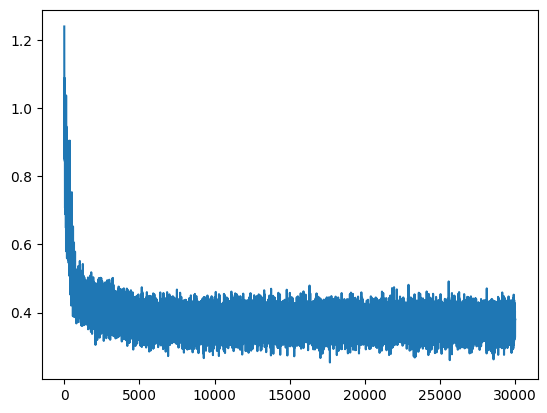

In [223]:
plt.plot(stepi , lossi)

In [224]:
def sample_words(count , word_list):
    for i in range(count):
        context = [0]*block_size
        word=""
        while(True):
            emb = c[context]
            l1 = emb.view(-1,chdim*block_size)@w1 + b1
            l1=l1.tanh()
            l2 = l1@w2 + b2
            probs = F.softmax(l2 , dim=1)
            ix = torch.multinomial(probs , num_samples=1 , replacement=True , generator=g).item()
            if ix==0 :
                break
            ch = itos[ix]
            word+=ch
            context=context[1:]+[ix]
        word_list.append(word)





In [225]:
word_list=[]
sample_words(10 , word_list)

In [226]:
word_list

['ardenona',
 'joliea',
 'djy',
 'alianeulenod',
 'rkon',
 'ienen',
 'iva',
 'anthnio',
 'faddaminosauravaynetyry',
 'efa']